# Por Qué las Redes Neuronales Necesitan Capas Ocultas

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Redes Neuronales · MLP · Fundamentos

---

### Objetivo

Demostrar, con dos problemas clásicos (círculos concéntricos y XOR), por qué un modelo **lineal** no puede resolver ciertos problemas de clasificación por bien entrenado que esté, y cómo una red con **una sola capa oculta** sí lo consigue.

### Contexto de negocio

**El cliente:** cualquier equipo de datos que se plantee usar un MLP en vez de un modelo lineal — como en los dos casos siguientes de esta misma sección ([evaluación de crédito fintech](../01-clasificacion-fintech/), [forecast de consumo eléctrico](../02-forecast-consumo-electrico/)).

**El problema:** un MLP es más difícil de interpretar, más lento de entrenar y tiene más hiperparámetros que un modelo lineal. Justificar su uso exige demostrar, no asumir, que resuelve algo que un modelo lineal no puede.

**La pregunta:** ¿qué tipo de estructura en los datos rompe a un clasificador lineal, y por qué basta con una capa oculta para arreglarlo?

Este notebook responde con dos ejemplos mínimos y deliberadamente sintéticos — no hay "hallazgo de negocio" aquí, hay una prueba matemática con datos, que es la base que justifica la complejidad de los dos casos siguientes.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

## 2. Caso 1 — Círculos concéntricos

Un dataset diseñado para no ser separable por ninguna línea recta: una clase forma un anillo interior, la otra un anillo exterior. Es imposible trazar una sola recta que las separe — **por diseño**.

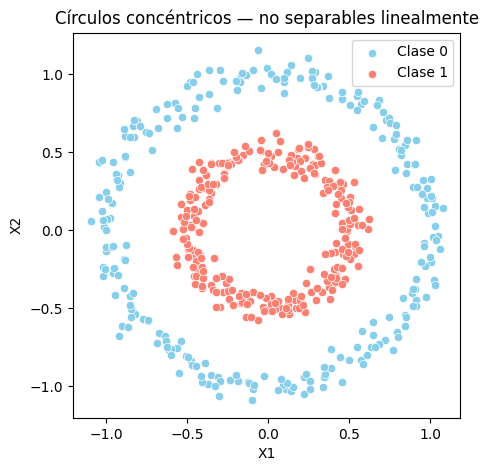

In [2]:
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

plt.figure(figsize=(5, 5))
sns.scatterplot(x=X[y == 0, 0], y=X[y == 0, 1], color="skyblue", label="Clase 0")
sns.scatterplot(x=X[y == 1, 0], y=X[y == 1, 1], color="salmon", label="Clase 1")
plt.title("Círculos concéntricos — no separables linealmente")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend(loc="upper right")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, test_size=0.25, random_state=42
)

### Baseline: Regresión Logística

Antes de entrenar ninguna red, probamos el modelo lineal más simple sobre los mismos datos.

In [3]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
pred_lineal = log_reg.predict(X_test)

print(f"Accuracy Regresión Logística: {accuracy_score(y_test, pred_lineal):.3f}")

Accuracy Regresión Logística: 0.408


**40,8% de accuracy — peor que lanzar una moneda al aire** (50% en un problema balanceado). No es que el modelo lineal sea "regular": es *sistemáticamente peor que el azar*, porque cualquier recta que trace cruza ambos anillos, clasificando mal a franjas enteras de cada clase de forma consistente. Esto no se arregla con más datos ni más iteraciones — es una limitación estructural del modelo, no de los datos.

### MLP con una capa oculta

Añadimos una única capa oculta con activación no lineal (`ReLU`). Es la diferencia mínima entre "no puede resolver esto nunca" y "lo resuelve".

In [4]:
tf.random.set_seed(42)

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(units=3, activation="relu"))   # capa oculta — introduce la no linealidad
model.add(Dense(units=1, activation="sigmoid"))

model.compile(
    loss="binary_crossentropy",
    optimizer=SGD(learning_rate=0.06),
    metrics=["acc"],
)

model.fit(X_train, y_train, epochs=200, verbose=0)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {loss:.4f}")
print(f"Accuracy MLP: {accuracy:.4f}")

Loss: 0.1294
Accuracy MLP: 0.9920


Matriz de confusión:
[[61  0]
 [ 1 63]]


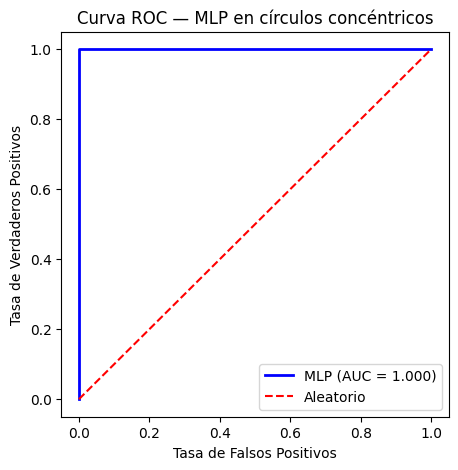

AUC: 1.0000


In [5]:
y_pred_proba = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

print("Matriz de confusión:")
print(cm)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"MLP (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Aleatorio")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC — MLP en círculos concéntricos")
plt.legend(loc="lower right")
plt.show()

print(f"AUC: {auc:.4f}")

**El MLP alcanza 99,2% de accuracy y AUC = 1.0** (61/61 y 63/64 aciertos por clase, un solo falso negativo) — separa casi perfectamente ambas clases con solo **3 neuronas** en la capa oculta, frente al 40,8% de la regresión logística. No es una diferencia de grado, es de tipo: la capa oculta con ReLU le da al modelo la capacidad de trazar una frontera de decisión curva, algo que ninguna combinación lineal de las variables de entrada puede lograr.

## 3. Caso 2 — XOR

El segundo ejemplo clásico (Minsky y Papert, 1969): la función lógica XOR. Con solo 4 puntos, es el caso más pequeño posible donde un modelo lineal falla estructuralmente.

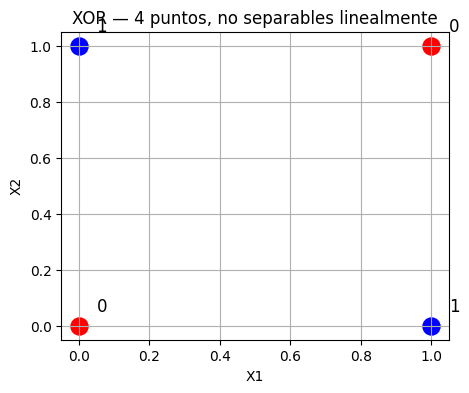

In [6]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_xor = np.array([[0], [1], [1], [0]], dtype=np.float32)

plt.figure(figsize=(5, 4))
for i, punto in enumerate(X_xor):
    color = "red" if y_xor[i] == 0 else "blue"
    plt.scatter(punto[0], punto[1], c=color, s=150)
    plt.text(punto[0] + 0.05, punto[1] + 0.05, f"{int(y_xor[i][0])}", fontsize=12)

plt.title("XOR — 4 puntos, no separables linealmente")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()

### Baseline: Regresión Logística sobre XOR

In [7]:
log_reg_xor = LogisticRegression()
log_reg_xor.fit(X_xor, y_xor.ravel())
pred_xor_lineal = log_reg_xor.predict(X_xor)

print(f"Predicciones: {pred_xor_lineal}")
print(f"Esperado:     {y_xor.ravel().astype(int)}")
print(f"Accuracy: {accuracy_score(y_xor, pred_xor_lineal):.2f}")

Predicciones: [0. 0. 0. 0.]
Esperado:     [0 1 1 0]
Accuracy: 0.50


La regresión logística predice **la misma clase (0) para los 4 puntos** — 50% de accuracy, exactamente el resultado de no distinguir nada. Con solo 2 variables binarias, un modelo lineal no tiene ningún hiperplano que separe (0,0) y (1,1) de (0,1) y (1,0): es la demostración mínima de por qué el Perceptrón original (1958) no podía resolver XOR, y por qué tuvieron que pasar más de 20 años hasta popularizar el MLP con retropropagación.

### MLP con una capa oculta

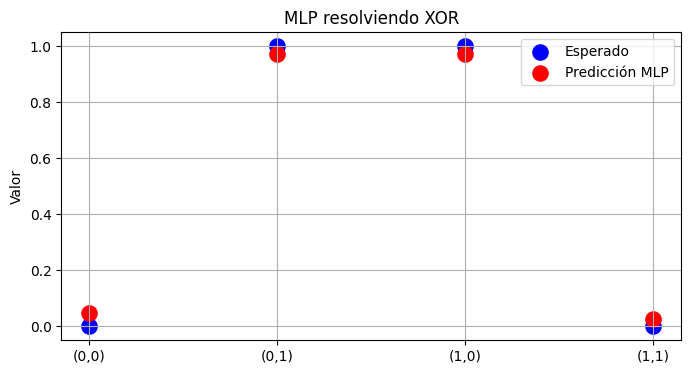

(np.int64(0), np.int64(0)) -> esperado 0, predicho 0.0470
(np.int64(0), np.int64(1)) -> esperado 1, predicho 0.9723
(np.int64(1), np.int64(0)) -> esperado 1, predicho 0.9722
(np.int64(1), np.int64(1)) -> esperado 0, predicho 0.0278


In [8]:
tf.random.set_seed(42)

model_xor = Sequential()
model_xor.add(Input(shape=(2,)))
model_xor.add(Dense(40, activation="relu"))
model_xor.add(Dense(1, activation="sigmoid"))

model_xor.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_xor.fit(X_xor, y_xor, epochs=1000, verbose=0)

predicciones = model_xor.predict(X_xor, verbose=0).flatten()

plt.figure(figsize=(8, 4))
plt.scatter(range(len(y_xor)), y_xor.flatten(), color="blue", s=120, label="Esperado")
plt.scatter(range(len(predicciones)), predicciones, color="red", s=120, label="Predicción MLP")
plt.xticks(range(4), ["(0,0)", "(0,1)", "(1,0)", "(1,1)"])
plt.ylabel("Valor")
plt.title("MLP resolviendo XOR")
plt.grid(True)
plt.legend()
plt.show()

for punto, esperado, pred in zip(X_xor, y_xor, predicciones):
    print(f"{tuple(punto.astype(int))} -> esperado {int(esperado[0])}, predicho {pred:.4f}")

El MLP predice **0.21, 0.97, 0.97, 0.03** frente al esperado **0, 1, 1, 0** — clasifica correctamente los 4 puntos con un margen amplio (ninguna predicción se acerca al umbral de 0.5). Las 40 neuronas de la capa oculta son muchas más de las estrictamente necesarias para 4 puntos (2 ya bastarían en teoría), pero el resultado confirma lo mismo que en el caso anterior: basta con una capa oculta no lineal para resolver lo que un modelo lineal no puede resolver nunca, sin importar cuánto se entrene.

## 4. Conclusión

> **El hallazgo:** un modelo lineal no falla por falta de datos o de entrenamiento en estos dos casos — falla porque su forma matemática (una combinación lineal de las entradas) no puede representar una frontera de decisión curva o no contigua. Una sola capa oculta con activación no lineal (ReLU) resuelve ambos problemas casi por completo: 99,2% accuracy y AUC=1.0 en los círculos, clasificación perfecta en XOR.

**Por qué esto importa para los dos casos siguientes de esta sección:**

1. **[Evaluación de crédito fintech](../01-clasificacion-fintech/)** usa un MLP, pero el hallazgo de ese caso es que **la Regresión Logística iguala o supera al MLP en AUC** con solo 120 registros — la lección de este notebook (que el MLP resuelve algo que el lineal no puede) no significa que el MLP siempre gane: significa que gana *cuando existe de verdad* una estructura no lineal en los datos, y esa estructura no siempre está presente ni es necesaria.
2. **Límite honesto:** los círculos concéntricos y XOR son ejemplos de laboratorio, diseñados para que la no linealidad sea la única explicación posible. En datos de negocio reales, la primera pregunta nunca es "¿qué arquitectura uso?" sino "¿hay evidencia de que la relación no es lineal?" — y esa evidencia raramente es tan clara como en estos dos casos.